# Example: Predator-Prey dynamics

Here, we apply the constant minibatch and adaptive minibatch SMC ABC algorithms to estimate parameters for predator prey dynamics given by stochastic Lotka-Volterra with logistic growth in the prey population. For speed, we apply a vectorized Tau Leaping algorithm, limiting simulation time considerably for off-particle choices. The dynamics are given by the reaction network: 

In [3]:
#Inference classes
from smc_abc import smc_abc_iterator as abc_iter
import smc_abc_utils as utils
import smc_abc_schemes as schemes

#Simulator classes
import predator_prey
lv_sim = predator_prey.lotka_volterra

#Support
import numpy as np
from matplotlib import pyplot as plt


cwd appended to system path


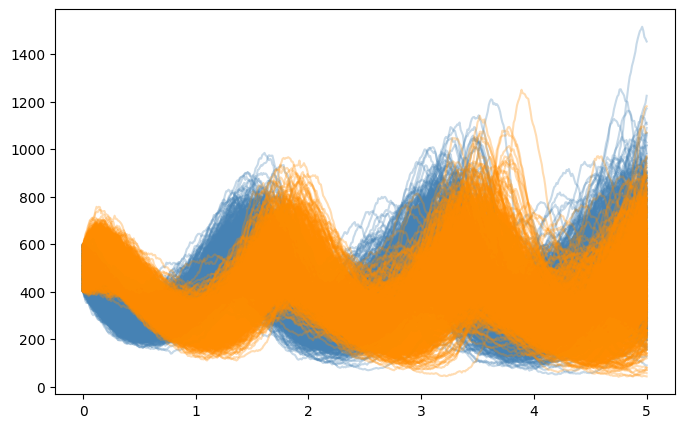

In [4]:
## Setup and tau leaping example
sample_size = 1000
alpha,beta,gamma,delta = 4,0.01,4,1
t_max = 5
dt = 0.01
ic = np.random.uniform(400,600,size=(sample_size,2))

times,ts = lv_sim.tau_leaping(ic,t_max,alpha,beta,gamma,delta,dt = dt,K = 10000)

fig,ax = plt.subplots(figsize = (8,5))
ax.plot(times,ts[:,:,0].T,color = 'steelblue',alpha = 0.3);
ax.plot(times,ts[:,:,1].T,color = 'darkorange',alpha = 0.3);

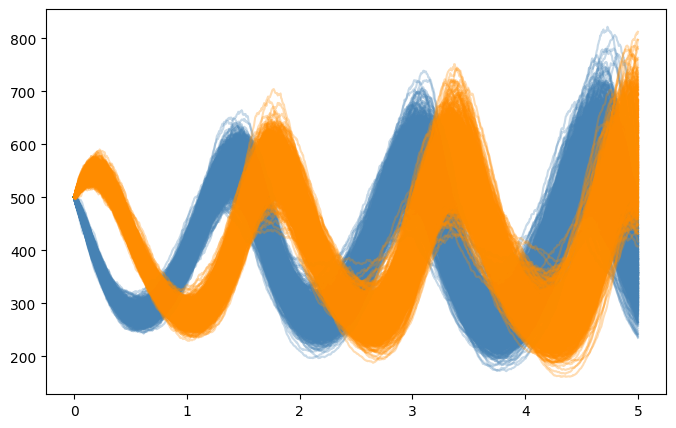

In [3]:
sigma = np.array([0.05,0.05])
times,ts = lv_sim.euler_maruyama(500*np.ones((sample_size,2)),t_max,alpha,beta,gamma,delta,sigma,dt = dt/2)

fig,ax = plt.subplots(figsize = (8,5))
ax.plot(times,ts[:,:,0].T,color = 'steelblue',alpha = 0.3);
ax.plot(times,ts[:,:,1].T,color = 'darkorange',alpha = 0.3);

data

In [4]:
## Setup and tau leaping example
sample_size = 2000
alpha,beta,gamma,delta = 4,0.01,4,1
K = 10000
t_max = 5
dt = 0.01
ic = np.random.uniform(400,600,size=(sample_size,2))

times,data = lv_sim.tau_leaping(ic,t_max,alpha,beta,gamma,delta,dt = dt,K = K)

print(np.sum(np.any(np.any(data == 0,axis=0),axis=1)))

0


In [8]:
#general parameters
num_particles = 300
cores = 4

##model
def model(p,Bi):
    alpha,beta,gamma = list(p)
    _,sim = lv_sim.tau_leaping(ic[Bi],t_max,alpha,beta,gamma,delta,dt = dt, K = K)
    obs = data[Bi]
    return sim, obs


#Stats function
def batch_corr(a, b):
    """Vectorized correlation between rows of a and b"""
    ma = a - np.mean(a, axis=1, keepdims=True)
    mb = b - np.mean(b, axis=1, keepdims=True)
    
    num = np.sum(ma * mb, axis=1)
    den = np.sqrt(np.sum(ma**2, axis=1) * np.sum(mb**2, axis=1))
    return num / (den + 1e-8)

def stats_func_lv(x, max_lag=5, step_size=10):
    r = x[:, :, 0]
    f = x[:, :, 1]
    
    # 1. Base Moments (Per-particle)
    stats_list = [
        np.log(np.mean(r, axis=1) + 1e-8),
        np.log(np.mean(f, axis=1) + 1e-8),
        np.log(np.var(r, axis=1) + 1),
        batch_corr(r, f) # Cross-correlation
    ]

    # 2. Add multiple Autocorrelation lags
    for i in range(1, max_lag + 1):
        lag = i * step_size # e.g., lags of 10, 20, 30, 40, 50 steps
        stats_list.append(batch_corr(r[:, :-lag], r[:, lag:]))
        stats_list.append(batch_corr(f[:, :-lag], f[:, lag:]))

    return np.column_stack(stats_list)
def stats_func(x,y,sf=stats_func_lv):
    return sf(x),sf(y)

prior = utils.uniform_prior([[0.0,10.0],[0.0,0.05],[0.0,10.0]])


init_params = {
    'data': data,
    'model': model,
    'stats_func':stats_func,
    'prior':prior,
    'num_particles':num_particles,
    'cores':cores
}

Running benchmarks...
Batch 8: 0.029653 sec
Batch 16: 0.030004 sec
Batch 32: 0.032467 sec
Batch 64: 0.037371 sec
Batch 128: 0.048076 sec
Batch 256: 0.069245 sec
Batch 512: 0.110946 sec
Average increase in seconds per sample: 0.0001410962629961432


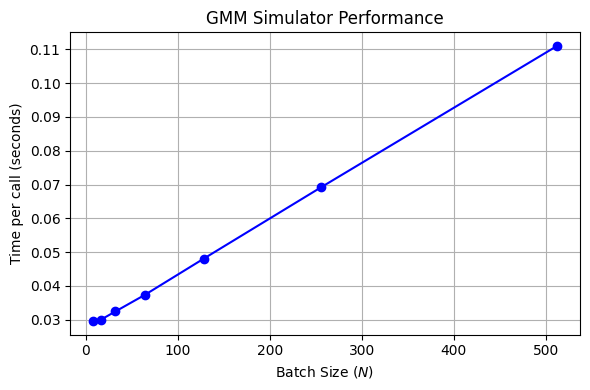

In [22]:
utils.benchmark_time([8,16,32,64,128,256,512],lambda n: model([alpha,beta,gamma],np.random.choice(sample_size,n)))

In [29]:
est = schemes.constant_init(init_params,[10])

while (est.snr > 2) and (est.acceptance_rate > 0.02):
    schemes.constant_loop(est)

700
Generation: 1. Batch Size: 10. Acceptance Rate: 1.000. Step time: 10.241. Total time 10.241. post-filter threshold: 103.7431. ESS: 500.00. Log HDPR vol: 1.088
Estimated v = 2670.622. Noise: v/n = 267.062. v/N = 1.335. Estimated c = 0.157. SNR: eps^2 / (v/n) = 40.300. Time per sim: 0.010
Generation: 2. Batch Size: 10. Acceptance Rate: 0.664. Step time: 12.894. Total time 23.136. post-filter threshold: 48.0221. ESS: 483.29. Log HDPR vol: 0.377
Estimated v = 396.583. Noise: v/n = 39.658. v/N = 0.198. Estimated c = 0.131. SNR: eps^2 / (v/n) = 58.150. Time per sim: 0.009
Generation: 3. Batch Size: 10. Acceptance Rate: 0.520. Step time: 16.320. Total time 39.456. post-filter threshold: 32.4386. ESS: 483.78. Log HDPR vol: -0.086
Estimated v = 115.089. Noise: v/n = 11.509. v/N = 0.058. Estimated c = 0.104. SNR: eps^2 / (v/n) = 91.430. Time per sim: 0.008
Generation: 4. Batch Size: 10. Acceptance Rate: 0.404. Step time: 20.835. Total time 60.291. post-filter threshold: 24.8315. ESS: 482.25.

In [ ]:
est = schemes.fvc_init(init_params,[2,None,0.5])

while (est.snr > 2) and (est.acceptance_rate > 0.02):
    schemes.fvc_loop(est)

### Special Example: Choosing replicate numbers

For some stochastic models, it makes sense to run multiple simulations and average the summary statistics for each observation. We will refer to these multiple runs replicates. For a single time series, we can define the weight matrix for mahalanobis distance as $W = diag(S_{obs})$, which allows us to calculate relative distance.

In [14]:
## Setup and tau leaping example
sample_size = 128
alpha,beta,gamma,delta = 4,0.01,4,1
K = 10000
t_max = 5
dt = 0.01
ic = np.random.uniform(400,600,size=(sample_size,2))

times,data = lv_sim.tau_leaping(ic,t_max,alpha,beta,gamma,delta,dt = dt,K = K)

print(np.sum(np.any(np.any(data == 0,axis=0),axis=1)))

0


In [ ]:
#general parameters
num_particles = 300
cores = 4

#Stats function
def batch_corr(a, b):
    """Vectorized correlation between rows of a and b"""
    ma = a - np.mean(a, axis=1, keepdims=True)
    mb = b - np.mean(b, axis=1, keepdims=True)
    
    num = np.sum(ma * mb, axis=1)
    den = np.sqrt(np.sum(ma**2, axis=1) * np.sum(mb**2, axis=1))
    return num / (den + 1e-8)

def stats_func_lv(x, max_lag=5, step_size=10):
    r = x[:, :, 0]
    f = x[:, :, 1]
    
    # 1. Base Moments (Per-particle)
    stats_list = [
        np.log(np.mean(r, axis=1) + 1e-8),
        np.log(np.mean(f, axis=1) + 1e-8),
        np.log(np.var(r, axis=1) + 1),
        batch_corr(r, f) # Cross-correlation
    ]

    # 2. Add multiple Autocorrelation lags
    for i in range(1, max_lag + 1):
        lag = i * step_size # e.g., lags of 10, 20, 30, 40, 50 steps
        stats_list.append(batch_corr(r[:, :-lag], r[:, lag:]))
        stats_list.append(batch_corr(f[:, :-lag], f[:, lag:]))

    return np.column_stack(stats_list)
def stats_func(x,y,sf=stats_func_lv):
    return sf(x),sf(y)

#three replicates is fairly standard
def model(p, Bi, num_reps=3):
    alpha,beta,gamma = p
    Bi_rep = np.repeat(Bi,repeats=num_reps)
    X0 = ic[Bi_rep]
    _, sim = lv_sim.tau_leaping(
        X0,t_max,
        alpha,beta,gamma,delta,
        dt=dt, K=K
    )
    s_sim = stats_func_lv(sim)
    obs = data[Bi_rep]
    s_obs = stats_func_lv(obs)
    return s_sim, s_obs


def stats_func(x,y,sf=stats_func_lv):
    return x,y

prior = utils.uniform_prior([[0.0,10.0],[0.0,0.05],[0.0,10.0]])

s_data = stats_func_lv(data)

init_params = {
    'data': s_data,
    'model': model,
    'stats_func':stats_func,
    'prior':prior,
    'num_particles':num_particles,
    'cores':cores
}

In [ ]:
est = schemes.fvc_init(init_params,p = [2,None,1.0])

while est.snr > 2:
    schemes.fvc_loop(est)